In [1]:
from network_models import growing_model as gm
from network_models import functions as f
from network_models import network_properties as net
import matplotlib.pyplot as plt
import h5py
import numpy as np

def get_degre_list(F):

    degree_list = []
    for i in range(100):
        d = np.array(F['degree_%s'%i])
        degree_list.extend(d)

    lb = f.log_binning_dist(0.1, degree_list)
    x, y = zip(*lb)
    return x, y

Growing network model where at each time step we add M nodes with L links. The linking probability of node i at time t is $P_i(t) = k_i^{\beta} (\tau)^{\alpha}$, where $\tau$ is age of node i. 

For $\alpha=0.0$ and $\beta=1.0$ it is Barabasi-Albert model, and generated networks have scale-free properties. 
Moving from this point scale free properties are lost.

Text(0, 0.5, 'P(degree)')

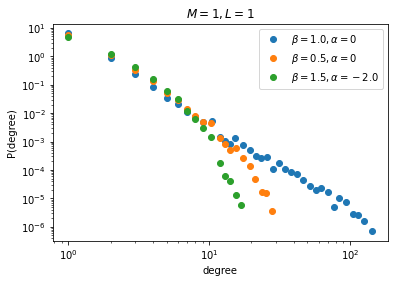

In [2]:
F = h5py.File('results/N1000_M1_L1_a0.0_b1.0_100samples.h5py')
x, y = get_degre_list(F)
plt.loglog(x, y, 'o', label = r'$\beta = 1.0, \alpha=0$')

F = h5py.File('results/N1000_M1_L1_a0.0_b0.5_100samples.h5py')
x, y = get_degre_list(F)
plt.loglog(x, y, 'o', label = r'$\beta = 0.5, \alpha=0.$' )

F = h5py.File('results/N1000_M1_L1_a-2.0_b1.5_100samples.h5py')
x, y = get_degre_list(F)
plt.loglog(x, y, 'o', label = r'$\beta = 1.5, \alpha=-2.0$'  )

plt.title(r'$M=1, L=1$')
plt.legend()
plt.xlabel("degree")
plt.ylabel("P(degree)")

The adaptation of model allow us to simulate real-world data.In  *model_time_series* number of new users follow some exact time series.

The degree distributions of networks generated from number of new users on MySpace for different parameters of $\alpha$ and $\beta$. For negative $\alpha$ and positive $\beta$ scale free properties can apear again. 

More details about phase transitions in $\alpha - \beta$ plain and the influence of growing signals on network structure can be  found in papers:

- [Growth signals determine the topology of evolving networks](https://iopscience.iop.org/article/10.1088/1742-5468/abd30b) Ana Vranić and Marija Mitrović Dankulov J. Stat. Mech. (2021) 

- [Phase transitions in an aging network](https://journals.aps.org/pre/abstract/10.1103/PhysRevE.70.056103) Kamalika Basu Hajra and Parongama Sen Phys. Rev. E 70, 056103 



Text(0, 0.5, 'P(degree)')

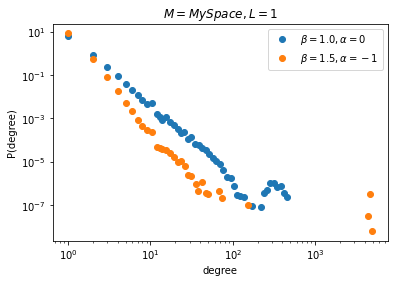

In [10]:
F = h5py.File('results/PT_10min_MySpace.data_M_L1_a0.0_b1.0_100samples.h5py')
x, y = get_degre_list(F)
plt.loglog(x, y, 'o',  label = r'$\beta = 1.0, \alpha=0$')

F = h5py.File('results/PT_10min_MySpace.data_M_L1_a-1.0_b1.5_100samples.h5py')
x, y = get_degre_list(F)
plt.loglog(x, y, 'o',  label = r'$\beta = 1.5, \alpha=-1.$')

plt.title(r'$M=MySpace, L=1$')
plt.legend()
plt.xlabel("degree")
plt.ylabel("P(degree)")
